In [57]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as font_manager
import scipy
import matplotlib as mpl
from scipy.special import gamma

STARTING_RANGE_PARAMETER = 0.0001 # In [fm^-2]
ENDING_RANGE_PARAMETER = 250
REDUCED_MASS = 935 * (4 / 5) # In [Mev / c^2], need to update value and units (10/11 A in MeV)
SUM_LIMIT = 20 # Determines the number of gaussians we expand our wave function to
LAMBDA_PARAM = 1000 * 1

V_LS = 11.71 # In MeV
DIFFUSIVITY = 0.6 # Diffusivity, may want to check the vaidity of this paticular number
r_0 = 1.2 # In fm, may want to chose a better value for small nuclei
A_C = 4 # The number of nucleons in the core
SIGMA = 2 #fm
TWO_PARTICLE_POTENTIAL_DEPTH = -24.22 # MeV

CENTRAL_POTENTIAL_PARAMETERS = [1 / ((2.30)**2)]

CENTRAL_MIXING_COEFFICIENTS = [1]

SPIN_ORBIT_POTENTIAL_PARAMETERS = [1 / (2.30**2)]

SPIN_ORBIT_MIXING_COEFFICIENTS = [1]

We start by doing the caclulation for He-5 to get the unphysical bound state to remove.

In [58]:
def single_particle_overlap(range_parameter_i, range_parameter_j):
    return ((2 * range_parameter_i * range_parameter_j) / (range_parameter_i**2 + range_parameter_j**2))**(1.5)

def single_particle_potential_element(range_parameter_i, range_parameter_j, central_potential_mixing_coefficient,
                             central_potential_param):
    V_0 = -47.32 * 2
    term_1 = 2 / (range_parameter_i * range_parameter_j)
    term_2 = 1 / ((1 / range_parameter_i**2) + (1 / range_parameter_j**2) + central_potential_param)
    return V_0 * central_potential_mixing_coefficient * (term_1 * term_2)**(1.5)

def single_particle_kinetic_element(range_parameter_i, range_parameter_j, μ=REDUCED_MASS):
    term_1 = range_parameter_i**2 + range_parameter_j**2
    return (197**2 / (2 * μ)) * 6 * single_particle_overlap(range_parameter_i, range_parameter_j) / term_1

def matrix_generation(central_mixing_coefficients=CENTRAL_MIXING_COEFFICIENTS,
                      central_potential_parameters=CENTRAL_POTENTIAL_PARAMETERS,
                      spin_orbit_potential_mixing_coefficients=SPIN_ORBIT_MIXING_COEFFICIENTS,
                      spin_orbit_potential_parameters=SPIN_ORBIT_POTENTIAL_PARAMETERS, size=SUM_LIMIT):
    h_matrix = np.zeros(shape=(size, size))
    n_matrix = np.zeros(shape=(size, size))

    for i in range(size):
        i_range_parameter = next_range_parameter(i)
        for j in range(size):
            j_range_parameter = next_range_parameter(j)
            kinetic_energy_term = single_particle_kinetic_element(i_range_parameter, j_range_parameter)
            potential_energy_term = 0
            for k in range(len(central_mixing_coefficients)):
                potential_energy_term += single_particle_potential_element(i_range_parameter,
                                                                  j_range_parameter, central_mixing_coefficients[k],
                                                                  central_potential_parameters[k])
            h_matrix[i, j] = kinetic_energy_term + potential_energy_term
            # h_matrix[j, i] = h_matrix[i, j]
            n_matrix[i, j] = single_particle_overlap(i_range_parameter, j_range_parameter)

    return h_matrix, n_matrix

def next_range_parameter(i, starting_range_parameter=STARTING_RANGE_PARAMETER, ending_range_parameter=ENDING_RANGE_PARAMETER,
                         sum_limit=SUM_LIMIT):
    """
    Finds the next range parameter given the previous and initial range parameters.
    Currently using a simple geometric series to determine range parameters.
    Chose geometric basis parameters $\alpha_i = \alpha_1a^{i-1}$ with initial parameters $\alpha_1 = 0.01, a=2$

    Parameters
    ----------
    i : int detailing the iteration number

    Returns
    -------
    new_range_parameter: float

    """
    geometric_progression_number = (ending_range_parameter / starting_range_parameter)**(1 / (sum_limit - 1))
    new_range_parameter = starting_range_parameter * geometric_progression_number**(i)
    #new_range_parameter = 1 / new_range_parameter**2

    return new_range_parameter

In [59]:
s_h_matrix, s_n_matrix = matrix_generation()
s_eigenvalues, s_eigenvectors = scipy.linalg.eigh(s_h_matrix, s_n_matrix)
s_overlap_eigenvalues, s_overlap_eigenvectors = scipy.linalg.eigh(s_n_matrix)
s_overlap_matrix_condition_number = np.max(s_overlap_eigenvalues) / np.min(s_overlap_eigenvalues)
#print(f"The s 1/2 overlap matrix condition number is", s_overlap_matrix_condition_number)

pauli_forbidden_eigenvector = (s_eigenvectors[:, 0])
#s1_eigenvector = s_eigenvectors[:, 1]
print("The S state eigenvalues are", s_eigenvalues)
#print("The S0 eigenvector is", pauli_forbidden_eigenvector)

The S state eigenvalues are [-3.89817691e+01 -4.62888477e-02  1.33308431e-03  1.03041573e-02
  6.46379674e-02  4.32100418e-01  2.56892843e+00  3.31475135e+01
  3.56914322e+02  1.98928000e+03  9.71777638e+03  4.61659641e+04
  2.18016072e+05  1.02826348e+06  4.84846226e+06  2.28603878e+07
  1.07793621e+08  5.08581302e+08  2.41015896e+09  1.18221940e+10]


Ground state wavefunction has overlap 0.9999999999999991 with itself


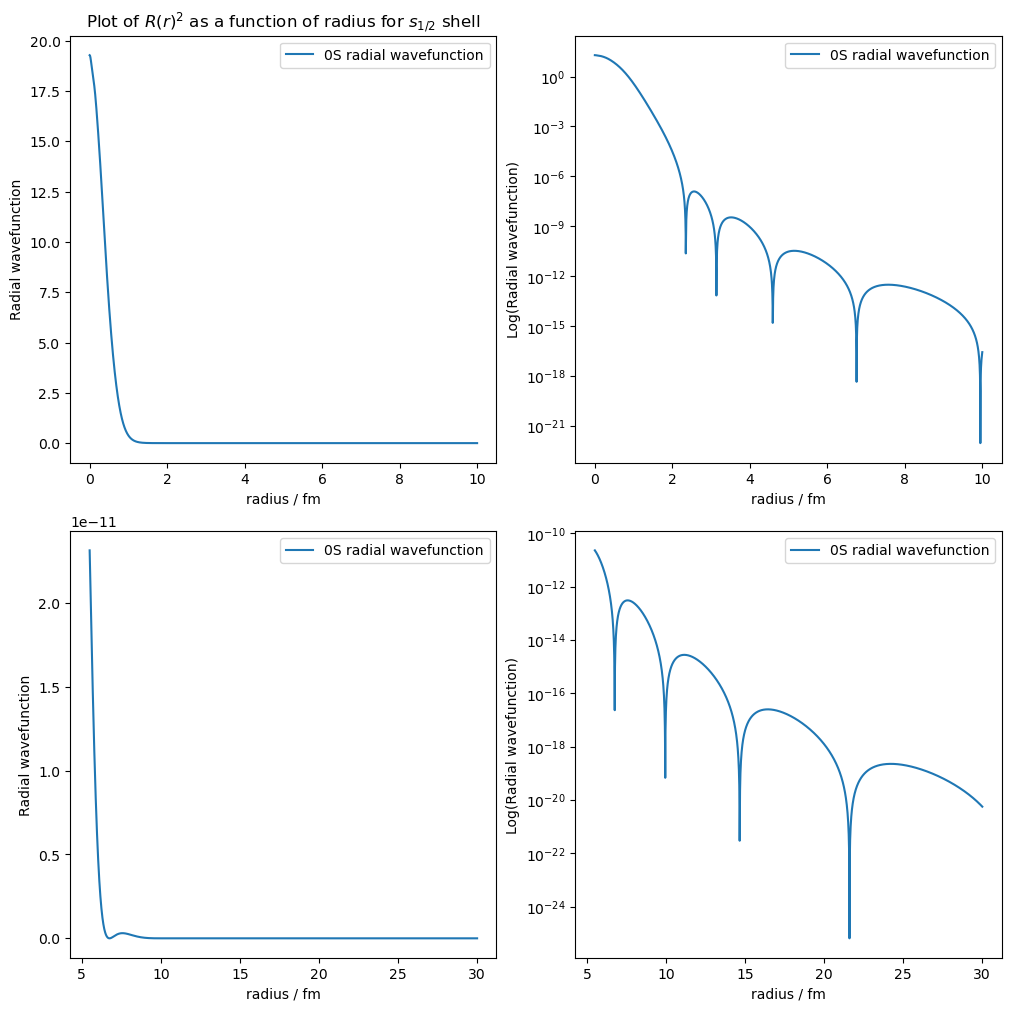

In [60]:
def wavefunction_overlap(orb_ang_momentum_i, orb_ang_momentum_j, i_mixing_coefficients,
                         j_mixing_coefficients, overlap_matrix, size=SUM_LIMIT):
    if orb_ang_momentum_i == orb_ang_momentum_j:
        return (np.asmatrix(i_mixing_coefficients) * overlap_matrix * np.transpose(np.asmatrix(i_mixing_coefficients)))[0, 0]
    else:
        print("Different states have orthongal angular components")
        return 0

print(f'Ground state wavefunction has overlap '
      f'{wavefunction_overlap(0, 0, pauli_forbidden_eigenvector, pauli_forbidden_eigenvector, overlap_matrix=s_n_matrix)}'
      f' with itself')

def radial_wavefunction(x_values, wavefunction_eigenvector, orbital_quantum_number, sum_limit=SUM_LIMIT):
    """
    Defines a numerical method of finding the reduced radial wavefunction as a sum of our gaussians.
    """
    def gaussian_wavefunction(radius, range_parameter, orb_ang_momentum):
        normalisation = (2**(-2.5 - orb_ang_momentum) * (range_parameter)**(3 + 2 * orb_ang_momentum) * gamma(1.5 + orb_ang_momentum))**(-0.5)
        return normalisation * radius**(orb_ang_momentum) * np.exp(- (radius / range_parameter)**2)
    wavefunction_vals = np.zeros(shape=(len(x_values),))

    for i in range(len(x_values)):
        for j in range(sum_limit):
            range_parameter = 1 / (next_range_parameter(j))**(0.5)
            wavefunction_vals[i] += (wavefunction_eigenvector[j] * gaussian_wavefunction(x_values[i], 
                range_parameter, orbital_quantum_number))
        wavefunction_vals[i] = wavefunction_vals[i]**2
    return wavefunction_vals

x_values = np.linspace(0, 10, 3000)
x_values_2 = np.linspace(5.5, 30, 3000)

fig = plt.figure(figsize=(10, 10), layout='constrained')
spec = fig.add_gridspec(ncols=2, nrows=2)
ax_1 = fig.add_subplot(spec[0,0])
ax_2 = fig.add_subplot(spec[0,1])
ax_3 = fig.add_subplot(spec[1,0])
ax_4 = fig.add_subplot(spec[1,1])
ax_1.set_title(r'Plot of $R(r)^{2}$ as a function of radius for $s_{1/2}$ shell')
ax_1.set_xlabel('radius / fm')
ax_1.set_ylabel('Radial wavefunction')
ax_1.plot(x_values, radial_wavefunction(x_values, pauli_forbidden_eigenvector, 0), label="0S radial wavefunction")
ax_1.legend()

ax_2.set_xlabel('radius / fm')
ax_2.set_ylabel('Log(Radial wavefunction)')
ax_2.semilogy(x_values, radial_wavefunction(x_values, pauli_forbidden_eigenvector, 0), label="0S radial wavefunction")
ax_2.legend()

ax_3.set_xlabel('radius / fm')
ax_3.set_ylabel('Radial wavefunction')
ax_3.plot(x_values_2, radial_wavefunction(x_values_2, pauli_forbidden_eigenvector, 0), label="0S radial wavefunction")
ax_3.legend()

ax_4.set_xlabel('radius / fm')
ax_4.set_ylabel('Log(Radial wavefunction)')
ax_4.semilogy(x_values_2, radial_wavefunction(x_values_2, pauli_forbidden_eigenvector, 0), label="0S radial wavefunction")
ax_4.legend()

We now use the pseudopotnetial method to remove the unphysical bound state. We construct the matrix elements using the $1s_{1/2}$ bound state and are found by,
$$V_{ij}^{\text{Pauli}} = \lambda \langle\ i|\psi_{f}\ \rangle\langle\ \psi_{f}|j\ \rangle = \lambda\left[\int d^{3}\vec{r}N_{i}\Phi_{i}(r)\sum_{k}c_{k}N_{k}\Phi_{k}(r)\right]\left[\int d^{3}\vec{r}\left(\sum_{l}c_{l}N_{l}\Phi_{l}(r)\right)N_{j}\Phi_{j}(r)\right]$$
$$=\lambda\left(\sum_{k}c_{k}O_{ik}\right)\left(\sum_{l}c_{l}O_{jl}\right)$$

In [61]:
PSUEDOPOTENTIAL_PARAM = 10**(3)#Lambda in the above expresion

def single_pseduopotential_mat_elem(range_param_i, range_param_j, mixing_coefficients, lambda_param, size=SUM_LIMIT):
    term_1 = 0
    term_2 = 0
    for k in range(size):
        k_range_param = next_range_parameter(k)
        term_1 += mixing_coefficients[k] * single_particle_overlap(range_param_i, k_range_param)
        term_2 += mixing_coefficients[k] * single_particle_overlap(k_range_param, range_param_j)
    return lambda_param * term_1 * term_2

def pseduopotential_matrix_generation(forbidden_state_mixing_coeffs, theta,
                                      central_mixing_coefficients=CENTRAL_MIXING_COEFFICIENTS,
                                      central_potential_parameters=CENTRAL_POTENTIAL_PARAMETERS,
                                      spin_orbit_potential_mixing_coefficients=SPIN_ORBIT_MIXING_COEFFICIENTS,
                                      spin_orbit_potential_parameters=SPIN_ORBIT_POTENTIAL_PARAMETERS, size=SUM_LIMIT,
                                     lambda_param=PSUEDOPOTENTIAL_PARAM):
    h_matrix = np.zeros(shape=(size, size))
    n_matrix = np.zeros(shape=(size, size))
    print(central_potential_parameters)
    print(central_mixing_coefficients)

    for i in range(size):
        i_range_parameter = next_range_parameter(i)
        for j in range(size):
            j_range_parameter = next_range_parameter(j)
            kinetic_energy_term = single_particle_kinetic_element(i_range_parameter, j_range_parameter)
            potential_energy_term = 0
            for k in range(len(central_mixing_coefficients)):
                potential_energy_term += single_particle_potential_element(i_range_parameter,
                                                                  j_range_parameter, central_mixing_coefficients[k],
                                                                  central_potential_parameters[k])
            h_matrix[i, j] = kinetic_energy_term + potential_energy_term + single_pseduopotential_mat_elem(
                i_range_parameter, j_range_parameter, forbidden_state_mixing_coeffs, lambda_param)
            n_matrix[i, j] = single_particle_overlap(i_range_parameter, j_range_parameter)

    return h_matrix, n_matrix

In [62]:
psuedo_s_h_matrix, psuedo_s_n_matrix = pseduopotential_matrix_generation(pauli_forbidden_eigenvector, 0)
psuedo_s_eigenvalues, psuedo_s_eigenvectors = scipy.linalg.eigh(psuedo_s_h_matrix, psuedo_s_n_matrix)
print(psuedo_s_eigenvalues)

[0.18903591682419663]
[1]
[-4.62888477e-02  1.33308431e-03  1.03041573e-02  6.46379674e-02
  4.32100418e-01  2.56892843e+00  3.31475135e+01  3.56914322e+02
  9.61018231e+02  1.98928000e+03  9.71777638e+03  4.61659641e+04
  2.18016072e+05  1.02826348e+06  4.84846226e+06  2.28603878e+07
  1.07793621e+08  5.08581302e+08  2.41015896e+09  1.18221940e+10]


We now want to impliment this in a correctly antisymmaterised calculation for He-6. We can keep the single matrix elements the same, and impliment the rest in accordance with our previous code, also including the antisymmaterised ground state.

In [63]:
def normalisation(range_parameter_i, range_parameter_j):
    return 1 / np.sqrt(2 * (1 - single_particle_overlap(range_parameter_i, range_parameter_j)))

def overlap_matrix_element(range_parameter_i, range_parameter_j, range_parameter_k, range_parameter_l):
    term_1 = single_particle_overlap(range_parameter_i, range_parameter_k) * single_particle_overlap(range_parameter_j, range_parameter_l)
    term_2 = single_particle_overlap(range_parameter_i, range_parameter_l) * single_particle_overlap(range_parameter_j, range_parameter_k)
    term_3 = normalisation(range_parameter_i, range_parameter_j) * normalisation(range_parameter_k, range_parameter_l)
    mat_elem = 2 * (term_1 - term_2) / term_3

    return mat_elem

def kinetic_matrix_element(range_parameter_i, range_parameter_j, range_parameter_k, range_parameter_l, μ=REDUCED_MASS, orb_ang_momentum=0):
    term_1 = single_particle_overlap(range_parameter_i, range_parameter_k) * single_particle_kinetic_element(
        range_parameter_j, range_parameter_l)
    term_2 = single_particle_overlap(range_parameter_j, range_parameter_l) * single_particle_kinetic_element(
        range_parameter_i, range_parameter_k)
    term_3 = single_particle_overlap(range_parameter_i, range_parameter_l) * single_particle_kinetic_element(
        range_parameter_j, range_parameter_k)
    term_4 = single_particle_overlap(range_parameter_j, range_parameter_k) * single_particle_kinetic_element(
        range_parameter_i, range_parameter_l)
    term_5 = normalisation(range_parameter_i, range_parameter_j) * normalisation(range_parameter_k, range_parameter_l)

    mat_elem = (term_1 + term_2 - term_3 - term_4) / term_5
    return mat_elem

def potential_matrix_element(range_parameter_i, range_parameter_j, range_parameter_k, range_parameter_l, central_potential_mixing_coefficient,
                             central_potential_param):
    term_1 = single_particle_overlap(range_parameter_i, range_parameter_k) * single_particle_potential_element(
        range_parameter_j, range_parameter_l, central_potential_mixing_coefficient, central_potential_param)
    term_2 = single_particle_overlap(range_parameter_j, range_parameter_l) * single_particle_potential_element(
        range_parameter_i, range_parameter_k, central_potential_mixing_coefficient, central_potential_param)
    term_3 = single_particle_overlap(range_parameter_i, range_parameter_l) * single_particle_potential_element(
        range_parameter_j, range_parameter_k, central_potential_mixing_coefficient, central_potential_param)
    term_4 = single_particle_overlap(range_parameter_j, range_parameter_k) * single_particle_potential_element(
        range_parameter_i, range_parameter_l, central_potential_mixing_coefficient, central_potential_param)
    term_5 = normalisation(range_parameter_i, range_parameter_j) * normalisation(range_parameter_k, range_parameter_l)

    mat_elem = (term_1 + term_2 - term_3 - term_4) / term_5
    return mat_elem

def distinguishable_interaction_matrix_element(range_parameter_i, range_parameter_j, range_parameter_k, range_parameter_l,
                                               potential_parameter, potential_strength=TWO_PARTICLE_POTENTIAL_DEPTH):
    def single_particle_norm(range_parameter):
        return (2 / (np.pi * range_parameter**2))**(0.75)

    term_A = range_parameter_i**(-2) + range_parameter_k**(-2) + potential_parameter**(-2)
    term_B = range_parameter_j**(-2) + range_parameter_l**(-2) + potential_parameter**(-2)
    term_1 = (term_A * term_B - potential_parameter**(-4))**(-1.5)
    return np.pi**3 * potential_strength * single_particle_norm(range_parameter_i) * single_particle_norm(
        range_parameter_j) * single_particle_norm(range_parameter_k) * single_particle_norm(
        range_parameter_l) * term_1

def interaction_matrix_element(range_parameter_i, range_parameter_j, range_parameter_k, range_parameter_l, potential_parameter,
                              potential_strength=TWO_PARTICLE_POTENTIAL_DEPTH):
    term_1 = distinguishable_interaction_matrix_element(range_parameter_i, range_parameter_j, range_parameter_k,
                                                          range_parameter_l, potential_parameter)
    term_2 = distinguishable_interaction_matrix_element(range_parameter_j, range_parameter_i, range_parameter_l,
                                                         range_parameter_k, potential_parameter)
    term_3 = distinguishable_interaction_matrix_element(range_parameter_i, range_parameter_j, range_parameter_l,
                                                          range_parameter_k, potential_parameter)
    term_4 = distinguishable_interaction_matrix_element(range_parameter_j, range_parameter_i, range_parameter_k,
                                                          range_parameter_l, potential_parameter)
    mat_elem = normalisation(range_parameter_i, range_parameter_j) * normalisation(range_parameter_k, range_parameter_l) * (
         term_1 + term_2 - term_3 - term_4)
    return mat_elem

def single_pseduopotential_mat_elem(range_param_i, range_param_j, mixing_coefficients, lambda_param, size=SUM_LIMIT):
    term_1 = 0
    term_2 = 0
    for k in range(size):
        k_range_param = next_range_parameter(k)
        term_1 += mixing_coefficients[k] * single_particle_overlap(range_param_i, k_range_param)
        term_2 += mixing_coefficients[k] * single_particle_overlap(k_range_param, range_param_j)
    return lambda_param * term_1 * term_2

def pseduopotential_mat_elem(range_parameter_i, range_parameter_j, range_parameter_k, range_parameter_l,
                             mixing_coefficients, lambda_param):
    term_1 = single_particle_overlap(range_parameter_i, range_parameter_k) * single_pseduopotential_mat_elem(
        range_parameter_j, range_parameter_l, mixing_coefficients, lambda_param)
    term_2 = single_particle_overlap(range_parameter_j, range_parameter_l) * single_pseduopotential_mat_elem(
        range_parameter_i, range_parameter_k, mixing_coefficients, lambda_param)
    term_3 = single_particle_overlap(range_parameter_i, range_parameter_l) * single_pseduopotential_mat_elem(
        range_parameter_j, range_parameter_k, mixing_coefficients, lambda_param)
    term_4 = single_particle_overlap(range_parameter_j, range_parameter_k) * single_pseduopotential_mat_elem(
        range_parameter_i, range_parameter_l, mixing_coefficients, lambda_param)
    term_5 = normalisation(range_parameter_i, range_parameter_j) * normalisation(range_parameter_k, range_parameter_l)

    mat_elem = (term_1 + term_2 - term_3 - term_4) / term_5
    return mat_elem

In [64]:
def two_particle_basis_matrix_generation(forbidden_state_mixing_coeffs,
                                         central_mixing_coefficients=CENTRAL_MIXING_COEFFICIENTS,
                                         central_potential_parameters=CENTRAL_POTENTIAL_PARAMETERS,
                                         size=SUM_LIMIT, potential_parameter=SIGMA,
                                         lambda_param=LAMBDA_PARAM):
    mat_size = int(size * (size - 1) * 0.5)
    first_h_matrix = np.zeros(shape=(mat_size, mat_size))
    second_h_matrix = np.zeros(shape=(mat_size, mat_size))
    interaction_matrix = np.zeros(shape=(mat_size, mat_size))
    overlap_matrix = np.zeros(shape=(mat_size, mat_size))
    A = -1
    B = -1

    for I in range(1, size**2 + 1):
        i = np.mod((I - 1), size) + 1
        i_range_parameter = next_range_parameter(i - 1)
        j = np.floor((I - 1) / size) + 1
        j_range_parameter = next_range_parameter(j - 1)
        if i < j:
            A += 1
            B = -1
            for J in range(1, size**2 + 1):
                k = np.mod((J - 1), size) + 1
                k_range_parameter = next_range_parameter(k - 1)
                l = np.floor((J - 1) / size) + 1
                l_range_parameter = next_range_parameter(l - 1)
                if k < l:
                    B += 1
                    overlap_matrix[A, B] = overlap_matrix_element(i_range_parameter, j_range_parameter,
                                                                  k_range_parameter, l_range_parameter)
                    interaction_matrix[A, B] = interaction_matrix_element(i_range_parameter, j_range_parameter,
                                                                          k_range_parameter, l_range_parameter,
                                                                          potential_parameter)
                    pseudopotential_term = pseduopotential_mat_elem(i_range_parameter, j_range_parameter,
                                                                    k_range_parameter, l_range_parameter,
                                                                    forbidden_state_mixing_coeffs, lambda_param)
                    first_potential_energy_term = 0
                    first_kinetic_term = kinetic_matrix_element(i_range_parameter, j_range_parameter,
                                                                k_range_parameter, l_range_parameter)
                    for m in range(len(central_mixing_coefficients)):
                        first_potential_energy_term += potential_matrix_element(
                            i_range_parameter, j_range_parameter, k_range_parameter, l_range_parameter,
                            central_mixing_coefficients[m], central_potential_parameters[m])
                    first_h_matrix[A, B] = first_kinetic_term + first_potential_energy_term + pseudopotential_term

                    second_potential_energy_term = 0
                    second_kinetic_term = kinetic_matrix_element(i_range_parameter, j_range_parameter,
                                                                 k_range_parameter, l_range_parameter)
                    for m in range(len(central_mixing_coefficients)):
                        second_potential_energy_term += potential_matrix_element(
                            i_range_parameter, j_range_parameter, k_range_parameter, l_range_parameter,
                            central_mixing_coefficients[m], central_potential_parameters[m])
                    second_h_matrix[A, B] = second_kinetic_term + second_potential_energy_term + pseudopotential_term
                else:
                    continue

        else:
            continue
                

    np.savetxt('nmatrix.csv', overlap_matrix)
    np.savetxt('h1matrix.csv', first_h_matrix)
    np.savetxt('h2matrix.csv', second_h_matrix)
    np.savetxt('interaction.csv', interaction_matrix)
    
    return first_h_matrix + second_h_matrix + interaction_matrix, overlap_matrix

In [65]:
h_matrix, n_matrix = two_particle_basis_matrix_generation(pauli_forbidden_eigenvector)


s_eigenvalues, s_eigenvectors = scipy.linalg.eigh(h_matrix, n_matrix)
#bound_states = np.real(s_eigenvalues) < 0
s_overlap_eigenvalues, s_overlap_eigenvectors = scipy.linalg.eigh(n_matrix)
s_overlap_matrix_condition_number = np.max(s_overlap_eigenvalues) / np.min(s_overlap_eigenvalues)
print(f"The s 1/2 overlap matrix condition number is", s_overlap_matrix_condition_number)

s0_eigenvector = np.asmatrix(s_eigenvectors[:, 0])
s1_eigenvector = np.asmatrix(s_eigenvectors[:, 1])
print("The S state eigenvalues are", s_eigenvalues)
#print(f'The bound states have energies {bound_states}')
#print("The S1 eigenvector is", s1_eigenvector)
print(f'The bound states have energies{np.real(np.sort(s_eigenvalues[np.real(s_eigenvalues) < 0]))}')

The s 1/2 overlap matrix condition number is 1821.4254122562213
The S state eigenvalues are [-4.49557658e-02 -3.59848679e-02  1.16372234e-02  1.83359067e-02
  6.59710252e-02  7.49390274e-02  3.85033304e-01  4.33431890e-01
  4.42387506e-01  4.96340915e-01  2.45118333e+00  2.57019970e+00
  2.57826491e+00  2.62617572e+00  2.90432398e+00  2.53372592e+01
  3.31486907e+01  3.31556368e+01  3.31889148e+01  3.33701353e+01
  3.40363136e+01  3.23684224e+02  3.56810786e+02  3.56915590e+02
  3.56923826e+02  3.56968595e+02  3.57334819e+02  3.58571126e+02
  9.59070374e+02  9.61019423e+02  9.61026540e+02  9.61062072e+02
  9.61265479e+02  9.62353203e+02  9.77686117e+02  1.30690528e+03
  1.98734239e+03  1.98928120e+03  1.98928837e+03  1.98932489e+03
  1.98953309e+03  1.99099321e+03  2.00244180e+03  2.25820873e+03
  2.94550799e+03  9.71733660e+03  9.71777761e+03  9.71778513e+03
  9.71782550e+03  9.71809133e+03  9.71992667e+03  9.74439008e+03
  1.00417106e+04  1.06749862e+04  1.16132613e+04  4.61656544e+0

Wavefunction energy -0.04495576584735884 has overlap 0.9999999999999984 with itself


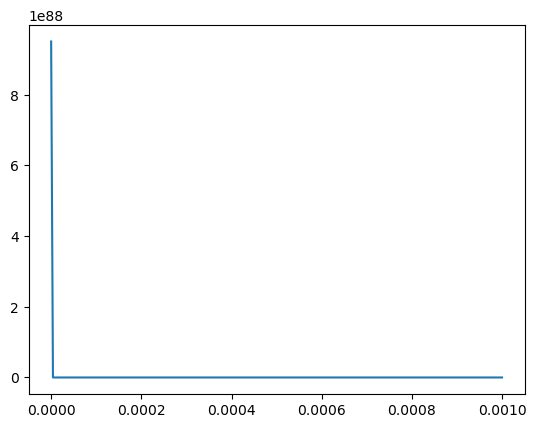

In [66]:
def radial_wavefunction(x_values, wavefunction_eigenvector, orbital_quantum_number, sum_limit=int(0.5 * SUM_LIMIT * (SUM_LIMIT - 1))):
    """
    Defines a numerical method of finding the reduced radial wavefunction as a sum of our gaussians.
    """
    def gaussian_wavefunction(radius, range_parameter, orb_ang_momentum):
        normalisation = (2**(-2.5 - orb_ang_momentum) * (range_parameter)**(3 + 2 * orb_ang_momentum) * gamma(1.5 + orb_ang_momentum))**(-0.5)
        return normalisation * radius**(orb_ang_momentum) * np.exp(- (radius / range_parameter)**2)
    wavefunction_vals = np.zeros(shape=(len(x_values),))

    for i in range(len(x_values)):
        for j in range(sum_limit):
            range_parameter = 1 / (next_range_parameter(j))**(0.5)
            wavefunction_vals[i] += (wavefunction_eigenvector[j] * gaussian_wavefunction(x_values[i], 
                range_parameter, orbital_quantum_number))
        wavefunction_vals[i] = wavefunction_vals[i]**2
    return wavefunction_vals

wavefunc_index = 0

print(f'Wavefunction energy {s_eigenvalues[wavefunc_index]} has overlap '
      f'{wavefunction_overlap(0, 0, s_eigenvectors[:, wavefunc_index], s_eigenvectors[:, wavefunc_index], overlap_matrix=n_matrix)}'
      f' with itself')

r_vals = np.linspace(0, 0.001, 250)
fig = plt.figure()
ax = fig.add_subplot()
ax.plot(r_vals, radial_wavefunction(r_vals, s_eigenvectors[:, wavefunc_index], 0))